# How to read and write rotated grids

In [1]:
import nes
import matplotlib
import matplotlib.pyplot as plt
import geopandas as gpd

In [2]:
%matplotlib inline

## 1. Open dataset

In [3]:
# Original path: /gpfs/scratch/bsc32/bsc32538/mr_multiplyby/OUT/stats_bnds/monarch/a45g/regional/daily_max/O3_all/O3_all-000_2021080300.nc
# Rotated grid from MONARCH
path = '/gpfs/projects/bsc32/models/NES_tutorial_data/O3_all-000_2021080300.nc'

In [4]:
nessy = nes.open_netcdf(path=path, info=True)
nessy

### Read projection

In [5]:
nessy.projection

<Other Coordinate Operation Transformer: ob_tran>
Description: PROJ-based coordinate operation
Area of Use:
- undefined

In [6]:
nessy.projection_data

{'grid_mapping_name': 'rotated_latitude_longitude',
 'grid_north_pole_latitude': np.float32(39.0),
 'grid_north_pole_longitude': np.float32(-170.0)}

### Read coordinates

In [7]:
nessy.time

[datetime.datetime(2021, 8, 3, 0, 0)]

In [8]:
nessy.lev

{'data': masked_array(data=[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0,
                    11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0,
                    20.0, 21.0, 22.0, 23.0],
              mask=[False, False, False, False, False, False, False, False,
                    False, False, False, False, False, False, False, False,
                    False, False, False, False, False, False, False, False],
        fill_value=1e+20),
 'dimensions': ('lev',),
 'dtype': dtype('float64'),
 'units': '',
 'positive': 'up'}

In [9]:
nessy.rlat

{'data': masked_array(data=[-27.0, -26.799999237060547, -26.600000381469727,
                    -26.399999618530273, -26.200000762939453, -26.0,
                    -25.799999237060547, -25.600000381469727,
                    -25.399999618530273, -25.200000762939453, -25.0,
                    -24.799999237060547, -24.600000381469727,
                    -24.399999618530273, -24.200000762939453, -24.0,
                    -23.799999237060547, -23.600000381469727,
                    -23.399999618530273, -23.200000762939453, -23.0,
                    -22.799999237060547, -22.600000381469727,
                    -22.399999618530273, -22.200000762939453, -22.0,
                    -21.799999237060547, -21.600000381469727,
                    -21.399999618530273, -21.200000762939453, -21.0,
                    -20.799999237060547, -20.600000381469727,
                    -20.399999618530273, -20.200000762939453, -20.0,
                    -19.799999237060547, -19.600000381469727,
      

In [10]:
nessy.rlon

{'data': masked_array(data=[-35.0, -34.79999923706055, -34.599998474121094,
                    -34.400001525878906, -34.20000076293945, -34.0,
                    -33.79999923706055, -33.599998474121094,
                    -33.400001525878906, -33.20000076293945, -33.0,
                    -32.79999923706055, -32.599998474121094,
                    -32.400001525878906, -32.20000076293945, -32.0,
                    -31.799999237060547, -31.600000381469727,
                    -31.399999618530273, -31.200000762939453, -31.0,
                    -30.799999237060547, -30.600000381469727,
                    -30.399999618530273, -30.200000762939453, -30.0,
                    -29.799999237060547, -29.600000381469727,
                    -29.399999618530273, -29.200000762939453, -29.0,
                    -28.799999237060547, -28.600000381469727,
                    -28.399999618530273, -28.200000762939453, -28.0,
                    -27.799999237060547, -27.600000381469727,
            

Variables are built with `rlat`, `rlon`, `lev` and `time`as main dimensions, but the coordinates `lat` and `lon` remain accessible

In [11]:
nessy.lat

{'data': masked_array(
   data=[[16.350337982177734, 16.43292999267578, 16.515146255493164, ...,
          16.515146255493164, 16.43292999267578, 16.350337982177734],
         [16.52742576599121, 16.610239028930664, 16.692676544189453, ...,
          16.692676544189453, 16.61024284362793, 16.52742576599121],
         [16.704471588134766, 16.787508010864258, 16.870166778564453, ...,
          16.870166778564453, 16.78750991821289, 16.704471588134766],
         ...,
         [58.32094955444336, 58.47268295288086, 58.62430953979492, ...,
          58.62430953979492, 58.47268295288086, 58.32094955444336],
         [58.42628479003906, 58.57820129394531, 58.73002624511719, ...,
          58.73002624511719, 58.57820129394531, 58.42628479003906],
         [58.530792236328125, 58.682899475097656, 58.83491897583008, ...,
          58.83491897583008, 58.68290328979492, 58.530792236328125]],
   mask=[[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False,

In [12]:
nessy.lon

{'data': masked_array(
   data=[[-22.181264877319336, -22.016672134399414, -21.85179901123047,
          ..., 41.8517951965332, 42.016666412353516, 42.18125915527344],
         [-22.278179168701172, -22.11318588256836, -21.947904586791992,
          ..., 41.947898864746094, 42.11317443847656, 42.27817153930664],
         [-22.375267028808594, -22.20987319946289, -22.044189453125, ...,
          42.044185638427734, 42.20987319946289, 42.37526321411133],
         ...,
         [-67.57766723632812, -67.39706420898438, -67.21534729003906, ...,
          87.21533966064453, 87.39705657958984, 87.5776596069336],
         [-67.9018783569336, -67.72247314453125, -67.54193878173828, ...,
          87.54193878173828, 87.72245788574219, 87.90187072753906],
         [-68.22803497314453, -68.04981994628906, -67.87051391601562, ...,
          87.8705062866211, 88.04981994628906, 88.22803497314453]],
   mask=[[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, F

### Read variables

In [13]:
nessy.keep_vars('O3_all')
nessy.load()

Rank 000: Loading O3_all var (1/1)
Rank 000: Loaded O3_all var ((1, 24, 271, 351))


In [14]:
nessy.variables['O3_all']

{'data': array([[[[2.82636070e-09, 2.83436141e-09, 2.82522827e-09, ...,
           2.96334601e-09, 2.94810221e-09, 2.91839553e-09],
          [2.80930834e-09, 2.57182142e-09, 2.55521360e-09, ...,
           2.56395216e-09, 2.55890820e-09, 2.89073032e-09],
          [2.79031842e-09, 2.53415999e-09, 2.50317100e-09, ...,
           2.56737764e-09, 2.58685584e-09, 2.85498758e-09],
          ...,
          [4.54469973e-09, 2.31674457e-09, 2.22753971e-09, ...,
           3.90127353e-09, 3.89643118e-09, 3.95452204e-09],
          [4.54129534e-09, 3.39469808e-09, 2.30205255e-09, ...,
           3.88824706e-09, 3.88372090e-09, 3.95252631e-09],
          [4.55012028e-09, 4.54941684e-09, 4.55885596e-09, ...,
           3.93945099e-09, 3.94256938e-09, 3.94736510e-09]],
 
         [[1.61966751e-09, 1.62850033e-09, 1.62801062e-09, ...,
           1.74583636e-09, 1.74684045e-09, 1.74125825e-09],
          [1.60704539e-09, 1.41438683e-09, 1.39824063e-09, ...,
           1.43241041e-09, 1.45136980e-09,

## 2. Plot

In [15]:
nessy.create_spatial_bounds()
lon_bnds, lat_bnds = nessy.get_spatial_bounds_mesh_format()

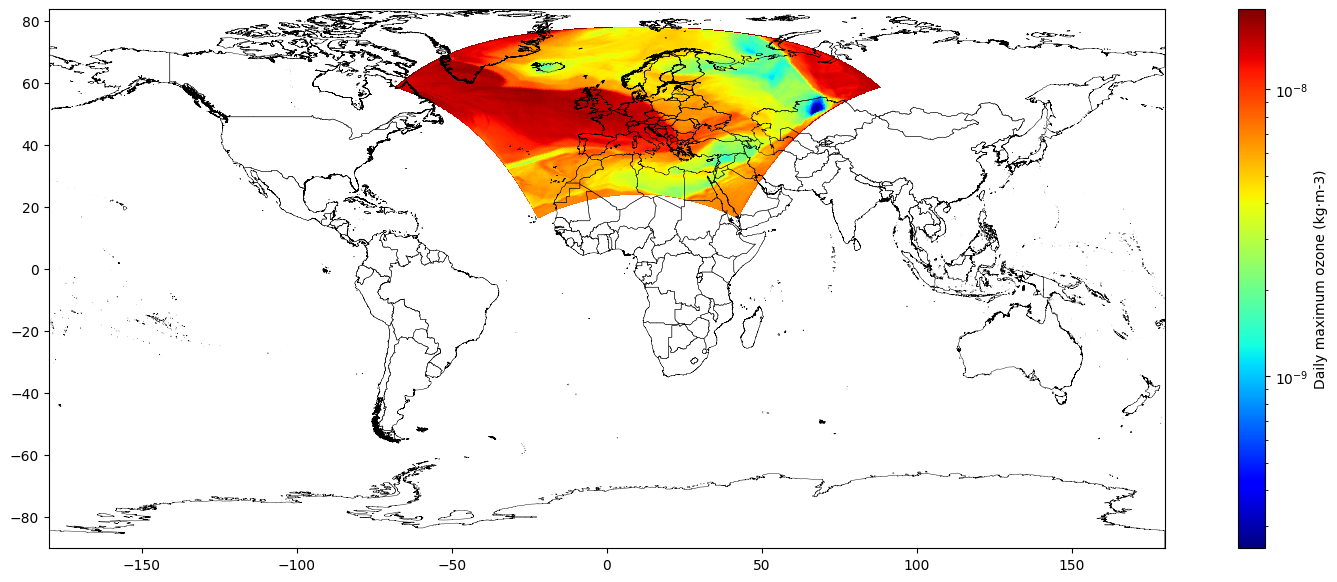

In [16]:
fig, ax = plt.subplots(1, figsize=(19, 7))
plt.pcolormesh(lon_bnds, lat_bnds, nessy.variables['O3_all']['data'].sum(axis=(0, 1)), cmap='jet', 
               norm=matplotlib.colors.LogNorm())
countries = gpd.read_file('/gpfs/projects/bsc32/models/NES_tutorial_data/gadm_country_mask/gadm_country_ISO3166.shp')
countries.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.3)
plt.colorbar(ax=ax, label='Daily maximum ozone (kg·m-3)')
ax.margins(0)

## 2. Write dataset

### Write NetCDF

In [17]:
nessy.to_netcdf('rotated_grid.nc', info=True)

Rank 000: Creating rotated_grid.nc
Rank 000: NetCDF ready to write
Rank 000: Dimensions done
Rank 000: Writing O3_all var (1/1)
Rank 000: Var O3_all created (1/1)
Rank 000: Filling O3_all
Rank 000: Var O3_all data (1/1)
Rank 000: Var O3_all completed (1/1)


### Write shapefile

In [18]:
nessy.to_shapefile('rotated_grid_shp')

/home/bsc/bsc032781/.local/lib/python3.9/site-packages/nes/nc_projections/default_nes.py:3805: UserWarning: No vertical level has been specified. The first one will be selected.
  warn(msg)
/home/bsc/bsc032781/.local/lib/python3.9/site-packages/nes/nc_projections/default_nes.py:3816: UserWarning: No time has been specified. The first one will be selected.
  warn(msg)
